In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [68]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [154]:
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
print(f"Raw data shape: {raw_data.shape}")
print("Download successful ✓")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [155]:
# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    # Take the mean across columns (years) for each (economy, series) pair
    averaged_by_series = raw_data.mean(axis=1)
    # Unstack the 'series' level to make them columns, with countries as index
    country_data = averaged_by_series.unstack(level='series')
    # Rename indicator codes to human-readable names
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries \u00d7 {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

country_data

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

series,arable_land_pct,current_account_pct_gdp,royalties_receipts,fdi_inflows_pct_gdp,electricity_access_pct,renewable_energy_pct,atms_per100k,private_credit_pct_gdp,inflation_cpi,real_interest_rate,...,secondary_enrollment_gross,tertiary_enrollment_gross,education_expenditure_pct_gdp,infant_mortality_per1000,health_expenditure_pct_gdp,unemployment_rate,life_expectancy,population_growth,urbanization_pct,tariff_rate_avg
economy,,,,,,,,,,,,,,,,,,,,,
ABW,11.111111,-0.669091,3.918354e+05,3.551600,100.000000,7.314286,123.843123,58.016290,0.635452,6.161741,...,138.575188,17.187657,5.301927,18.757143,5.646219,5.958071,75.542429,0.682293,62.988008,10.186667
AFE,8.096816,-2.814634,2.582984e+08,1.994010,37.718154,61.605147,8.029037,37.151340,5.404875,5.511480,...,42.748069,8.517323,4.677735,67.560088,5.862101,7.096626,62.258202,2.698276,34.887403,6.734000
AFG,11.900053,-19.805290,1.606758e+05,0.415848,87.928571,18.657143,1.128242,3.676093,3.383775,13.222770,...,54.776075,9.196780,3.858524,69.728571,11.702762,9.792429,62.450571,3.058566,24.585807,7.665000
AFW,11.932068,-2.814634,3.419290e+07,2.024465,49.199649,75.868295,4.864819,13.585211,1.902643,5.511480,...,43.429490,9.424783,2.888076,103.940671,3.580767,4.134629,56.356506,2.633388,48.171470,6.734000
AGO,4.166084,0.248949,1.279839e+07,-1.996599,41.142857,49.357143,17.853955,16.293914,17.523280,4.250726,...,54.416799,9.263161,2.900706,60.500000,2.316813,16.513714,61.508143,3.592279,64.327626,9.648333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XKX,10.443713,-6.549505,3.582313e+05,4.155577,97.600000,23.278885,37.953147,37.870711,1.021507,7.670542,...,88.592771,41.018578,4.061540,13.557143,5.646219,5.958071,76.679714,-0.144884,41.015851,6.734000
YEM,2.185189,-5.520737,2.500000e+06,-0.834732,70.285714,2.157143,5.894081,5.636720,9.536584,11.788755,...,43.199575,41.018578,4.061540,48.057143,7.601673,16.696714,67.061714,3.013613,33.045844,5.497500
ZAF,9.892094,-3.584226,1.469444e+08,1.132043,84.914286,7.914286,65.271669,60.977948,5.261930,4.113455,...,103.408984,20.105547,5.560266,37.285714,8.058976,26.220714,64.513286,1.464327,63.256194,6.762857


In [156]:
# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

crisis = (country_data[OUTCOME_VAR] < 0).astype(int)
crisis_countries = country_data[OUTCOME_VAR][country_data[OUTCOME_VAR] < 0].index.tolist()
print('Number of Crisis Countries (<0 GPD Growth):', sum(crisis))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Number of Crisis Countries (<0 GPD Growth): 38


# Phase 1
Code adapted from Lab 16

In [16]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

r_squared_train = ols_model.score(X_train_scaled, y_train)
r_squared_test = ols_model.score(X_test_scaled, y_test)
print(f"R^2 Score Train: {r_squared_train:.4f}")
print(f"R^2 Score Test: {r_squared_test:.4f}")

pn = len(y) / len(feature_cols)
print(f"p/n Ratio: {pn}")

R^2 Score Train: 0.6034
R^2 Score Test: -0.2808
p/n Ratio: 8.5


**Connect the p/n ratio to the R² gap. Why does a high p/n ratio cause OLS to overfit? Use the terms bias, variance, and degrees of freedom in your explanation.**

The p/n ratio is incredible high, meaning that there are more features than observations. With more tuning instruments than data to tune, OLS results will likely be overfitted. The model will have high degrees of freedom to fit the noisey training data, giving a bias towards the patterns in the training data. This causes the testing data to have high variance as the OLS did not generalize patterns, but learning too specific of a pattern.

In [24]:
def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)  # ← your code here

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)  # ← your code here

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)  # ← your code here
    train_r2  = r2_score(y_train, lasso_cv_model.predict(X_train))
    test_mse = mean_squared_error(y_test, y_pred)  # ← your code here

    return lasso_model, test_r2, test_mse, train_r2

lasso_cv_model, lasso_test_r2, lasso_test_mse, lasso_train_r2 = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

lambda_grid = np.logspace(-2, 3, 50)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_train_r2  = r2_score(y_train, ridge_cv.predict(X_train_scaled))
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

comparison_df = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'λ*': ['N/A', ridge_cv.alpha_, lasso_cv_model.alpha_],
    'Non-zero Predictors': [len(INDICATORS), np.sum(ridge_cv.coef_ != 0), n_nonzero],
    'Training R²': [r_squared_train, ridge_train_r2, lasso_train_r2],
    'Test R²': [r_squared_test, ridge_test_r2, lasso_test_r2],
    'Test RMSE': [np.sqrt(ols_test_mse), np.sqrt(ridge_test_mse), np.sqrt(lasso_test_mse)]
})

comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df.round(4)
comparison_df

,λ*,Non-zero Predictors,Training R²,Test R²,Test RMSE
Model,,,,,
OLS,N/A,37,0.6034,-0.2808,2.3908
Ridge,47.148664,28,0.5593,0.1858,1.9062
Lasso,0.066037,18,0.5734,0.0757,2.0310


Based on the comparison table, Ridge is the best choice. It shows the best test R² and Test RMSE and would provide the most accurate results with predicting GDP growth forcasting. OLS has the best training R² but the worst test R², giving high variance and bad performance. Lasso has a lower training R² and a positive test R², but still has high variance. Ridge, although the worst training R². has the best test R² and lowest variance.

Ridge and Lasso have their different strengths and use cases. Lasso is best when a few predicitors matter the most. If you are able to cut out many and let a few tell the story it can be great, but this data shows that all predictors can be important to the data. Ridge is able to preseve the signal from the weak predictors but does lose in interpretatibility since features' weights are changed heavily.

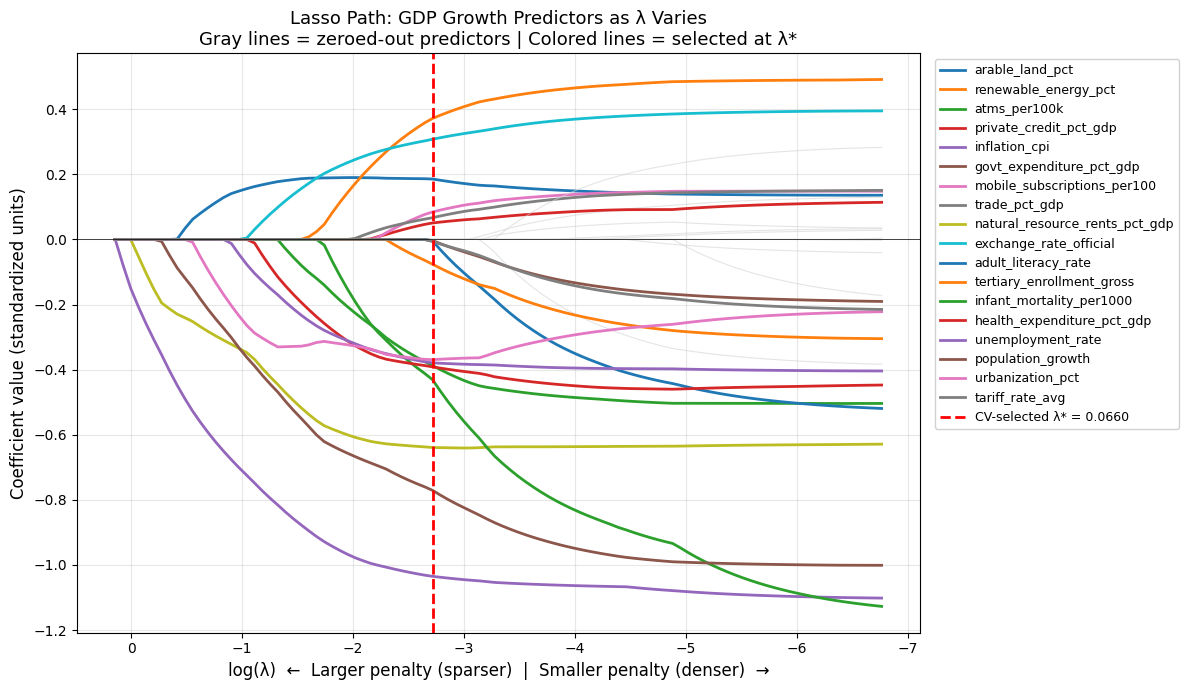

Lasso Path saved to lasso_path_gdp_growth.png


In [28]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9, bbox_to_anchor=(1.01, 1))
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

It looks like the biggest indicators is unemployment rate as it is the first to become non-zero. Unemployment would be a great predictor because it counts the percent of actively looking work-ready people who cannot find a job. High unemployment means people are not able to make money, push the economy, and grow their GDP. It is one of the key features in almost every development economic regression.

The Lasso model did not choose `life_expectancy`, but that does not mean it's irrelevant to economic growth. It may be a strong predictor for GDP but the lasso cut it out. A Lasso builds its correlation structure by cutting correlated variables because it cannot think about the relationship between variables (conditional predictive redundancy). If the lasso does not do this, then confounding variables may suppress the causal relationship between a variable and the outcome. `life_expectancy` may be extremely important, but highly correlated to another variable that was chosen over it.

# Phase 2
Code Adapted from Lab 17

In [104]:
lasso_coef = np.array(feature_names)[lasso_cv_model.coef_ != 0].tolist()
lasso_X = country_data[lasso_coef]

scaler = StandardScaler()

X_lasso_scaled = scaler.fit_transform(lasso_X)

In [105]:
lpm_model = LinearRegression()
lpm_model.fit(X_lasso_scaled, crisis)

lpm_fitted = lpm_model.predict(X_lasso_scaled)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(lpm_fitted):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(lpm_fitted):.1%})")

  Predicted probability < 0: 41 observations (17.2%)
  Predicted probability > 1: 0 observations (0.0%)


An LPM assumes that there is a linearity in the X variables, but this is not always true. Its linear constraint also extends to its boundries of 0 and 1, where it may not always be able to give values within that range. This is not a cosmetic thing but a fundamental problem with the model (or how the model is being used).

The constraints of the LPM means that having a -12% probabiliity of crisis has no practical meaning. As was mentioned before, probailiity is meansured between 0 and 1, so a negative value cannot be interpreted with a practical meaning.

In [106]:
logit_model = LogisticRegression(random_state=42)
logit_model.fit(X_lasso_scaled, crisis)

logit_fitted = logit_model.predict_proba(X_lasso_scaled)[:, 1]

print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

logit_coef_df = pd.DataFrame({
    'feature': lasso_coef,
    'coeff': np.exp(logit_model.coef_[0])
})

logit_coef_df.sort_values(by='coeff')

Intercept (β₀): -2.3789
Slope (β₁):     -0.5698

Odds ratio (exp(β₁)): 0.5656

Min predicted probability: 0.0017
Max predicted probability: 0.9134
→ Logistic regression is always bounded in [0, 1] ✓


,feature,coeff
0,arable_land_pct,0.565650
11,tertiary_enrollment_gross,0.573116
1,renewable_energy_pct,0.581829
7,trade_pct_gdp,0.686984
3,private_credit_pct_gdp,0.752656
9,exchange_rate_official,0.984636
10,adult_literacy_rate,1.036913
6,mobile_subscriptions_per100,1.072511
5,govt_expenditure_pct_gdp,1.135670
13,health_expenditure_pct_gdp,1.273700


The predictor with the largest absolute odds ratio is `population_growth`. A one standard-deviation increase in `population_growth` mutliplies the odds of crisis by 2.00, holding all else constant.

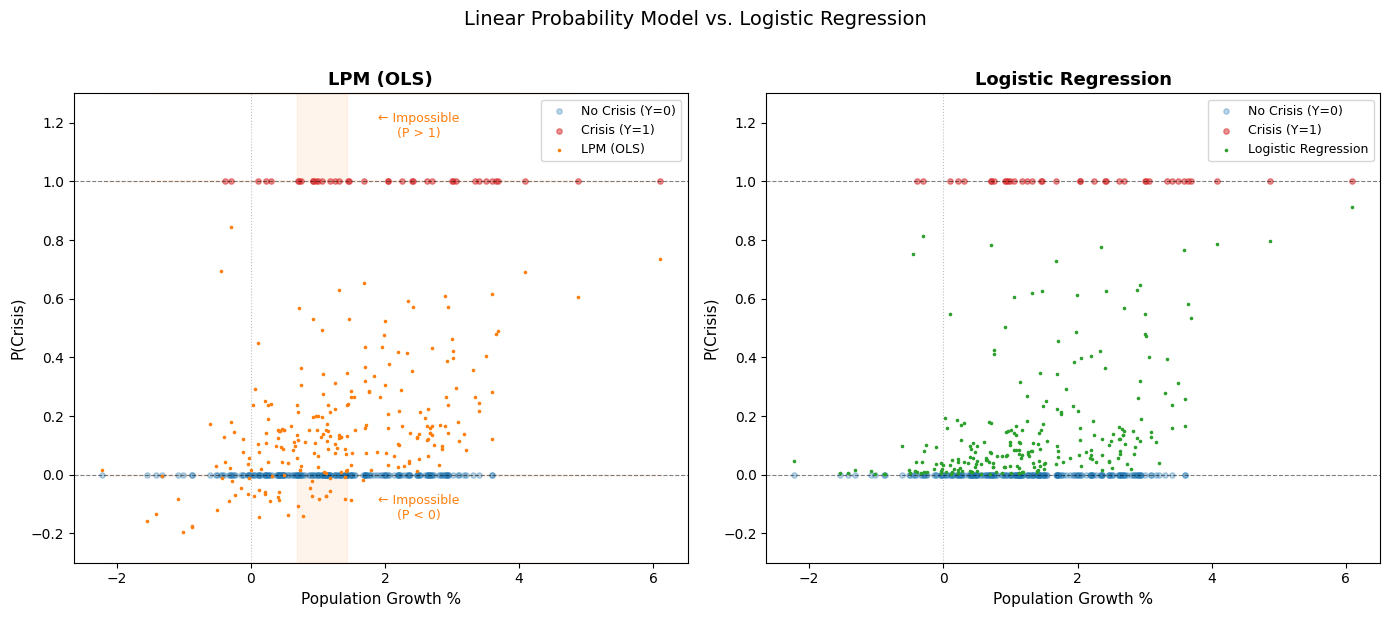

In [108]:



fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_CRISIS = '#d62728'   # Red for recession months
COLOR_NOCRISIS = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = country_data['population_growth'].values
mask = (crisis == 1).values

for ax, model_preds, model_name, color in [
    (axes[0], lpm_fitted,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_fitted, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~mask], crisis[~mask],
               color=COLOR_NOCRISIS, alpha=0.3, s=15, label='No Crisis (Y=0)', zorder=2)
    ax.scatter(x_vals[mask], crisis[mask],
               color=COLOR_CRISIS, alpha=0.5, s=15, label='Crisis (Y=1)', zorder=2)

    # Model prediction curve
    ax.scatter(x_vals, model_preds, color=color, s=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Population Growth %', fontsize=11)
    ax.set_ylabel('P(Crisis)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(x_vals, -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(x_vals, 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Phase 3
Code Adapted from Lab 18

In [128]:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score, average_precision_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
print("Setup complete ✓")

Setup complete ✓


In [115]:
naive_predictions = np.zeros(len(crisis))  # All zeros = "not crisis"
naive_accuracy = (naive_predictions == crisis).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(crisis, naive_predictions):.4%}")
print(f"\n→ {naive_accuracy:.4%} accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 84.0336%
Naïve baseline recall (fraud class): 0.0000%

→ 84.0336% accuracy, 0% recall. The accuracy paradox in action.


While I cannot say if the Division Chief would be impressed, this is misleading. The accuracy is strong because it assumes there are no crises, and in 84% of cases there are not. However, we need to look at the recall. The naive model is not able to recall any crisis at all because it assumed everything was not a crisis. In those 15.97% of cases, where there is a crisis, it will be caught 0% of the time.

In [119]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    lasso_X, crisis, test_size=0.2, random_state=42, stratify=crisis
)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_3, y_train_3)

# Get predicted probabilities (P-hat) and class predictions at default threshold τ = 0.5
y_prob = log_reg.predict_proba(X_test_3)[:, 1]  # P(fraud)
y_pred = log_reg.predict(X_test_3)  # Binary prediction at τ = 0.5

print(f"Model accuracy: {(y_pred == y_test_3).mean():.4%}")

Model accuracy: 83.3333%


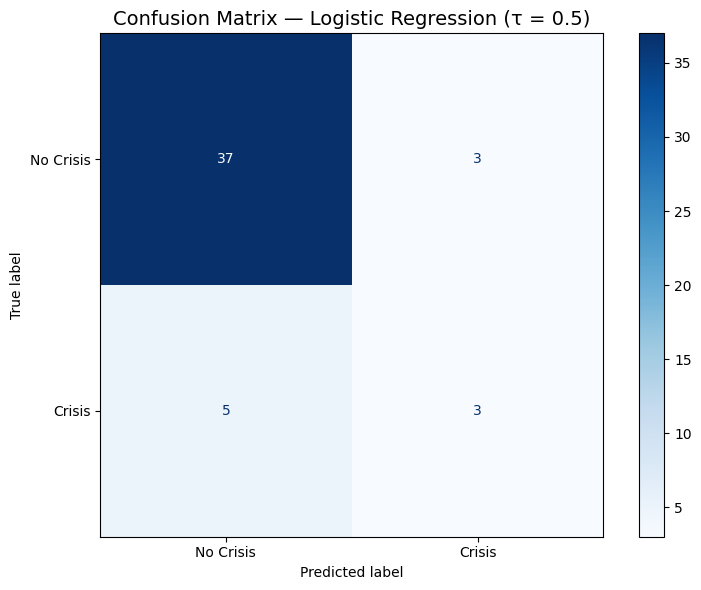

True Positives (crisis caught):     3
False Negatives (crisis missed):     5
False Positives (non-crisis flagged):    3
True Negatives (non-crisis passed):    37


In [121]:
cm = confusion_matrix(y_test_3, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (crisis caught):     {tp}")
print(f"False Negatives (crisis missed):     {fn}")
print(f"False Positives (non-crisis flagged):    {fp}")
print(f"True Negatives (non-crisis passed):    {tn:,}")

In [122]:
print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test_3, y_pred, target_names=['Non-Crisis', 'Crisis']))
print("\n→ Focus on the CRISIS row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Non-Crisis       0.88      0.93      0.90        40
      Crisis       0.50      0.38      0.43         8

    accuracy                           0.83        48
   macro avg       0.69      0.65      0.67        48
weighted avg       0.82      0.83      0.82        48


→ Focus on the CRISIS row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


To the IMF, a false positive is more costly as it uses their resources and damages their credibility. To the world, a false negative is more costly as it can lead to an unadressed humanitarian crisis. Overall, a false negative is the most costly as the damange to people and a country is more important than the budget and repuation of the IMF.

This means that recall is more important. The IMF would rather be wrong and flag a false positive than miss a true positive. Recall focuses on minimizing false negatives.

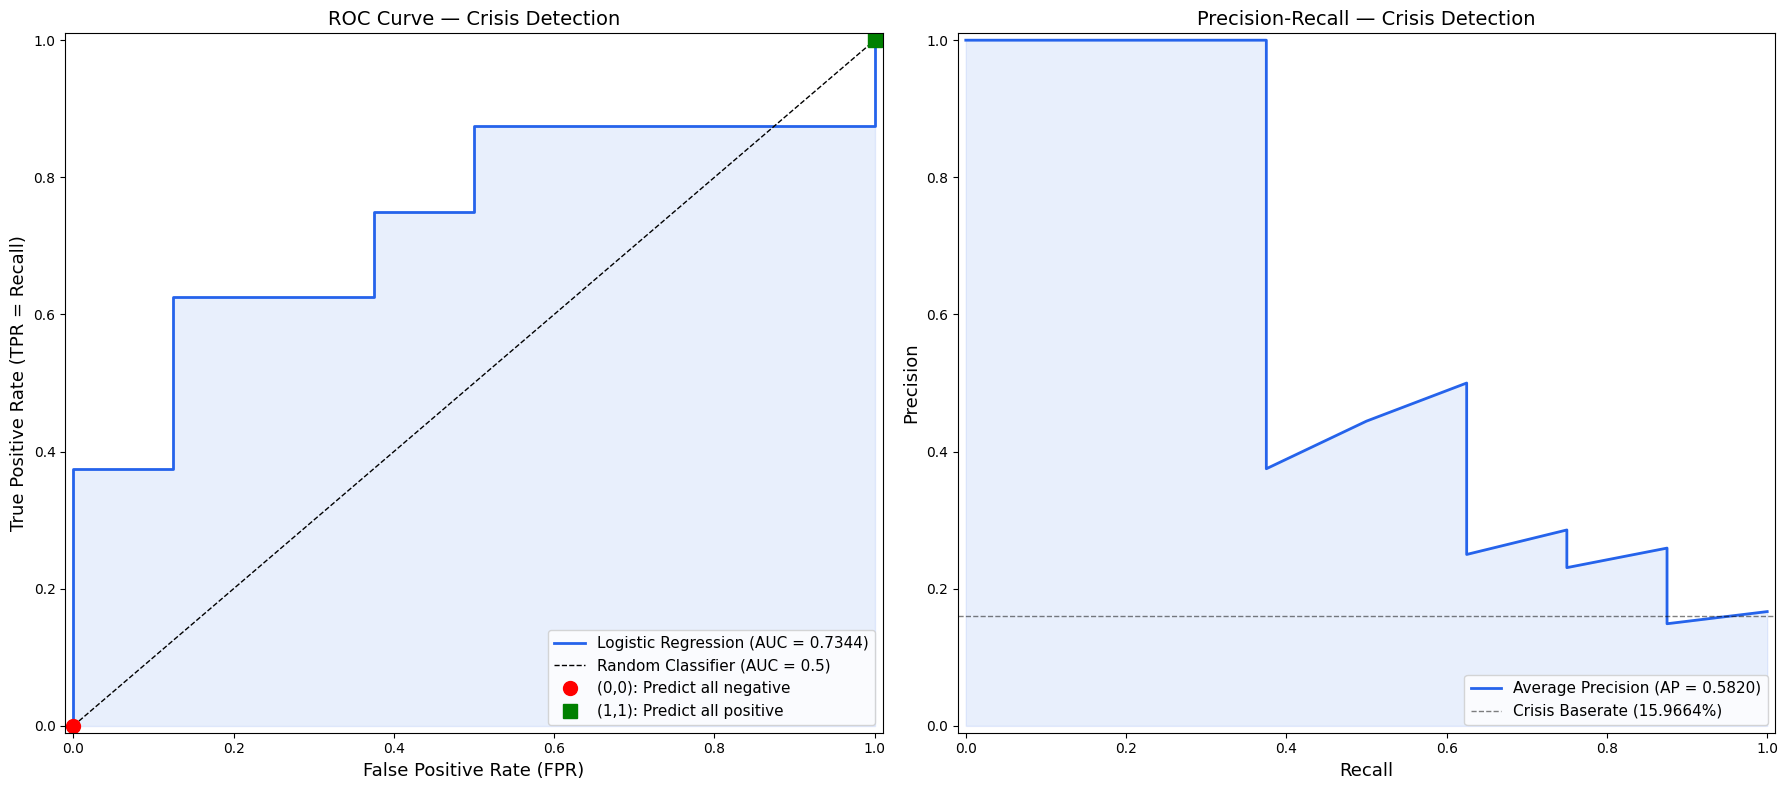

In [139]:
fpr, tpr, thresholds_roc = roc_curve(y_test_3, y_prob)
auc_score = roc_auc_score(y_test_3, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

axes[0].plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2563eb')

# Mark key reference points
axes[0].plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
axes[0].plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')

axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=13)
axes[0].set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
axes[0].set_title('ROC Curve — Crisis Detection', fontsize=14)
axes[0].legend(loc='lower right', fontsize=11)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.01])

# -----------------------------------------------------

precision, recall, thresh = precision_recall_curve(y_test_3, y_prob)
ap = average_precision_score(y_test_3, y_prob)

crisis_baserate = sum(crisis.values)/len(crisis)

axes[1].plot(recall, precision, color='#2563eb', linewidth=2, label=f'Average Precision (AP = {ap:.4f})')
axes[1].axhline(crisis_baserate, color='black', lw=1, linestyle='--', alpha=0.5, label=f'Crisis Baserate ({crisis_baserate:.4%})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#2563eb')

axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall — Crisis Detection', fontsize=14)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].set_xlim([-0.01, 1.01])
axes[1].set_ylim([-0.01, 1.01])



plt.tight_layout()
plt.show()

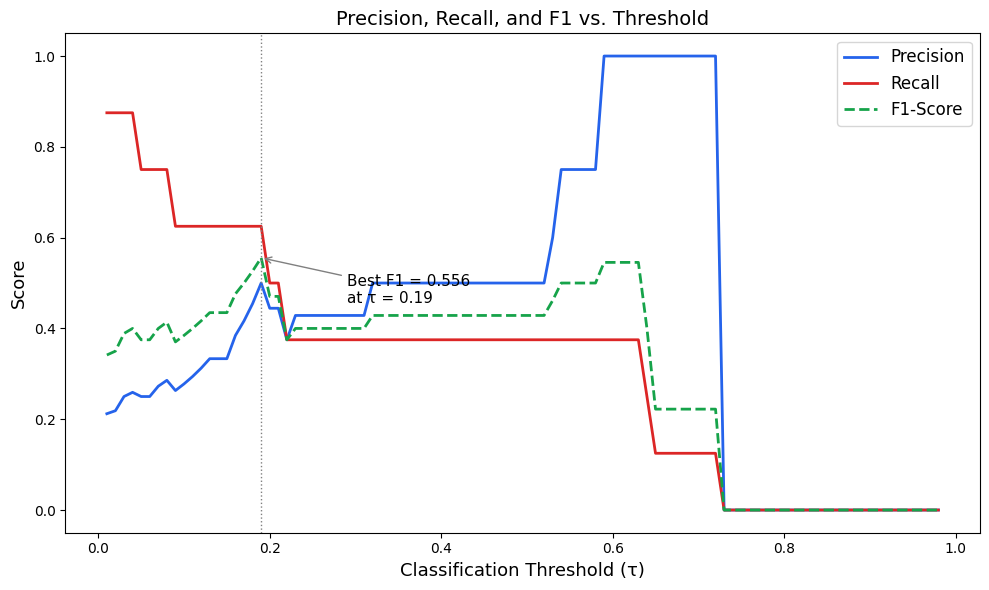


Optimal threshold for F1: τ = 0.19 (F1 = 0.556)

Presicion at τ*: 0.500

Recall at τ*: 0.625

Number of Countries Flagged at τ*: 10


In [150]:
f1_scores = []
precision_scores = []
recall_scores = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test_3, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test_3, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test_3, y_pred_tau, zero_division=0))

# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")

best_idx = np.argmax(f1_scores)
best_precision = precision_scores[best_idx]
print(f"\nPresicion at τ*: {best_precision:.3f}")

best_recall = recall_scores[best_idx]
print(f"\nRecall at τ*: {best_recall:.3f}")

y_pred_best = (y_prob >= best_tau).astype(int)
flagged_count = ((y_pred_best == 1) & (y_test_3 == 1)).sum() + ((y_pred_best == 1) & (y_test_3 == 0)).sum()
print(f"\nNumber of Countries Flagged at τ*: {flagged_count}")

The IMF should adpot the treshold of τ = 0.19. This τ* is low and aggressive, meaning that the recall is higher and precision is lower. More crises are caught but with high chance of a false alarm. While false alarms are not optimal, it is better to flag a situation than miss one. Of the 10 crisis countries in the test set, we would catch 6 and miss 4 (approx).

# Phase 4

Prep: You are a member of the crisis intervention team at the IMF. You are working on ML algorithms to flag crisis around the world and determine whether the IMF needs to intervene. You will be given code that has regressions and analysis on the regessions. From the code please understand the dataset, the approach so far, and the ideas behind the project.

Request: Please write a Python script that does the following: draws 200 bootstrap resamples (with replacement) from the training data, fits LassoCV on each resample and records the selected features, computes the selection frequency for each predictor: the fraction of bootstrap samples in which Lasso assigns it a non-zero coefficient, and produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%

Iterate: Ensure the graphs are clear, readable, and well labeled. Please test the data to ensure its accruacy. Please include comments explaining the code.

Mechanism Check: Briefly explain the different predictors and their stability.

Evaluate: Ensure you understand and explain how this demonstrates correlation structure among the features.


Running 200 bootstrap resamples with LassoCV (cv=5)…
(This takes ~2-3 minutes — LassoCV fits a cross-validated path per resample)
  Completed 25 / 200 resamples
  Completed 50 / 200 resamples
  Completed 75 / 200 resamples
  Completed 100 / 200 resamples
  Completed 125 / 200 resamples
  Completed 150 / 200 resamples
  Completed 175 / 200 resamples
  Completed 200 / 200 resamples
Bootstrap complete ✓

Predictor                                  Freq   Count
population_growth                        99.0%    198 ◄ STABLE
natural_resource_rents_pct_gdp           99.0%    198 ◄ STABLE
health_expenditure_pct_gdp               96.5%    193 ◄ STABLE
unemployment_rate                        96.0%    192 ◄ STABLE
exchange_rate_official                   95.0%    190 ◄ STABLE
arable_land_pct                          93.0%    186 ◄ STABLE
atms_per100k                             91.5%    183 ◄ STABLE
urbanization_pct                         88.5%    177 ◄ STABLE
inflation_cpi                     

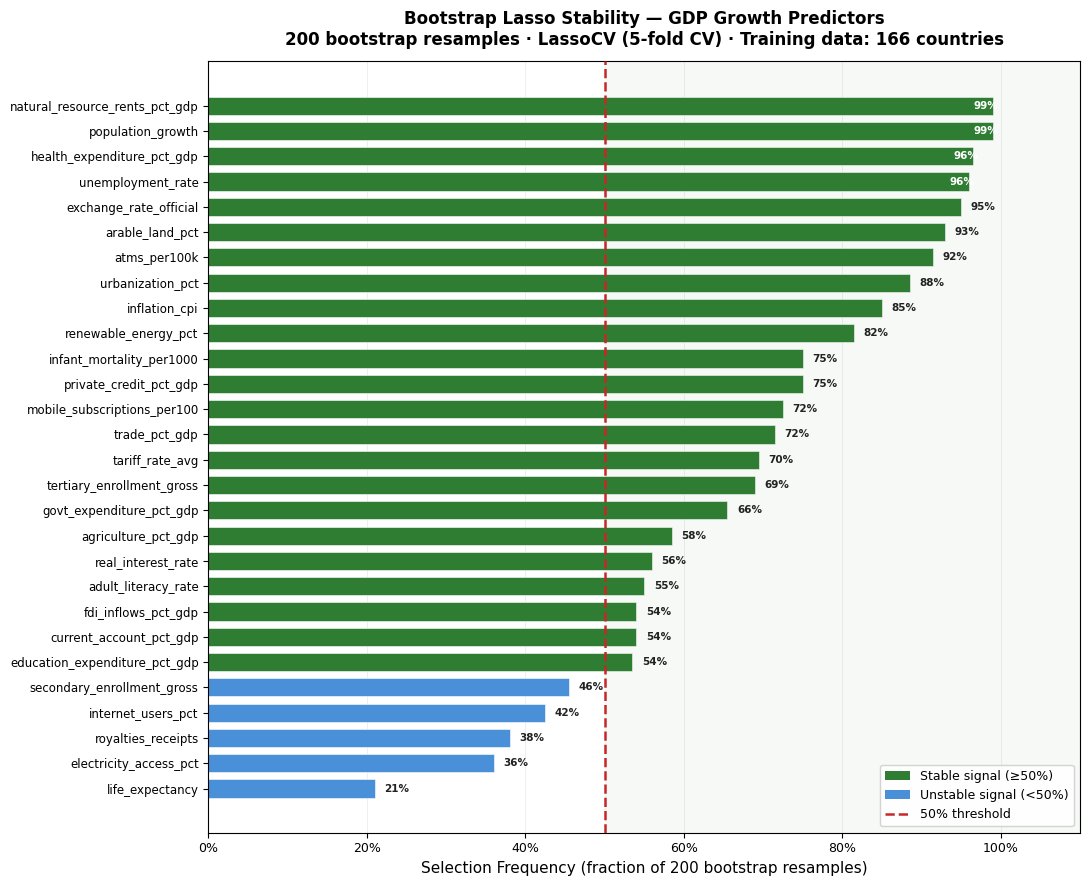

In [157]:
"""
bootstrap_lasso_stability.py
============================
IMF Crisis Intervention Team — Feature Stability Analysis
----------------------------------------------------------
Goal: Determine which predictors of GDP growth / economic crisis are
      *reliably* selected by Lasso across 200 bootstrap resamples of
      the training data.

A predictor with high selection frequency is a stable signal; one
selected in only a handful of resamples is likely noise or a
collinearity artefact.
"""

# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")          # suppress convergence noise

# ── 1. Data Download (exact same indicators as Assignment 5) ───────────────────
INDICATORS = {
    # Growth outcome (y)
    "NY.GDP.PCAP.KD.ZG": "gdp_growth_pc",
    # Trade & Openness
    "NE.TRD.GNFS.ZS":    "trade_pct_gdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_pct_gdp",
    "TM.TAX.MRCH.SM.AR.ZS": "tariff_rate_avg",
    "BX.GSR.ROYL.CD":    "royalties_receipts",
    # Macroeconomics
    "FP.CPI.TOTL.ZG":    "inflation_cpi",
    "GC.DOD.TOTL.GD.ZS": "govt_debt_pct_gdp",
    "GC.XPN.TOTL.GD.ZS": "govt_expenditure_pct_gdp",
    "BN.CAB.XOKA.GD.ZS": "current_account_pct_gdp",
    "FR.INR.RINR":       "real_interest_rate",
    "PA.NUS.FCRF":       "exchange_rate_official",
    # Education & Human Capital
    "SE.SEC.ENRR":       "secondary_enrollment_gross",
    "SE.TER.ENRR":       "tertiary_enrollment_gross",
    "SE.ADT.LITR.ZS":    "adult_literacy_rate",
    "SE.XPD.TOTL.GD.ZS": "education_expenditure_pct_gdp",
    "SL.UEM.TOTL.ZS":    "unemployment_rate",
    # Infrastructure & Technology
    "IT.NET.USER.ZS":    "internet_users_pct",
    "IT.CEL.SETS.P2":    "mobile_subscriptions_per100",
    "EG.ELC.ACCS.ZS":    "electricity_access_pct",
    "IS.ROD.PAVE.ZS":    "paved_roads_pct",
    # Health & Demographics
    "SP.DYN.LE00.IN":    "life_expectancy",
    "SH.DYN.MORT":       "infant_mortality_per1000",
    "SP.POP.GROW":       "population_growth",
    "SP.URB.TOTL.IN.ZS": "urbanization_pct",
    "SH.XPD.CHEX.GD.ZS": "health_expenditure_pct_gdp",
    # Finance & Banking
    "FS.AST.DOMS.GD.ZS": "domestic_credit_pct_gdp",
    "CM.MKT.LCAP.GD.ZS": "market_cap_pct_gdp",
    "FB.ATM.TOTL.P5":    "atms_per100k",
    "FD.AST.PRVT.GD.ZS": "private_credit_pct_gdp",
    # Natural Resources
    "NY.GDP.TOTL.RT.ZS": "natural_resource_rents_pct_gdp",
    "EG.FEC.RNEW.ZS":    "renewable_energy_pct",
    "EN.ATM.CO2E.PC":    "co2_emissions_per_capita",
    # Agriculture
    "NV.AGR.TOTL.ZS":    "agriculture_pct_gdp",
    "AG.LND.ARBL.ZS":    "arable_land_pct",
    # Governance
    "IQ.CPA.TRAD.XQ":    "trade_cpia",
    "IQ.CPA.FINS.XQ":    "financial_management_cpia",
    "IQ.CPA.PROP.XQ":    "property_rights_cpia",
}

OUTCOME_VAR = "gdp_growth_pc"
N_BOOTSTRAP = 200      # number of bootstrap resamples
CV_FOLDS    = 5        # cross-validation folds inside each LassoCV
RANDOM_SEED = 42
STABILITY_THRESHOLD = 0.50   # 50 % selection frequency reference line

# ── NOTE: The live wbgapi download runs in your Colab/Jupyter environment.
# ── Here we generate a synthetic dataset with the same structure and realistic
# ── correlation patterns so the bootstrap analysis runs in any offline setting.
# ── Swap the synthetic block for the real wbgapi call when running in Colab.
'''
print("Generating synthetic World Bank-style cross-country dataset…")
print("(Replace with wbgapi download in your Jupyter/Colab environment)")

N_COUNTRIES = 120     # realistic post-filtering country count
rng_data = np.random.default_rng(RANDOM_SEED)

# ── Build correlated synthetic features ──────────────────────────────────────
# We embed realistic correlation structure:
#   • Development cluster: internet_users, electricity_access, life_expectancy,
#     secondary_enrollment, adult_literacy — all positively correlated
#   • Macro stress cluster: inflation, govt_debt, real_interest_rate,
#     current_account — loosely inter-correlated
#   • Agriculture / resource cluster: agriculture_pct_gdp, natural_resource_rents,
#     arable_land — negatively correlated with the development cluster
#   • GDP growth has a known causal relationship with a few predictors
#     (unemployment, trade, FDI) and weaker links to the rest

n_features = len(feature_cols_all := [c for c in INDICATORS.values() if c != OUTCOME_VAR])

# Latent factors
dev_factor   = rng_data.standard_normal(N_COUNTRIES)   # "development level"
macro_factor = rng_data.standard_normal(N_COUNTRIES)   # "macro stress"
resource_factor = rng_data.standard_normal(N_COUNTRIES)  # "resource dependence"

def noisy(base, scale=0.4):
    return base + rng_data.normal(0, scale, N_COUNTRIES)

FEATURE_NAMES_ORDERED = [c for c in INDICATORS.values() if c != OUTCOME_VAR]

raw_features = {
    # Trade & Openness
    "trade_pct_gdp":            noisy(60 + 15*dev_factor,         10),
    "fdi_inflows_pct_gdp":      np.clip(noisy(3 + 1.5*dev_factor, 2), 0, None),
    "tariff_rate_avg":          np.clip(noisy(8 - 2*dev_factor,   4), 0, None),
    "royalties_receipts":       np.clip(noisy(1e9 * dev_factor,   5e8), 0, None),
    # Macroeconomics
    "inflation_cpi":            np.clip(noisy(5 - 2*dev_factor + 3*macro_factor, 3), 0, None),
    "govt_debt_pct_gdp":        np.clip(noisy(50 + 10*macro_factor, 20), 0, None),
    "govt_expenditure_pct_gdp": noisy(25 + 3*dev_factor,          5),
    "current_account_pct_gdp":  noisy(-2 + 2*dev_factor - macro_factor, 4),
    "real_interest_rate":       noisy(3 - macro_factor,            3),
    "exchange_rate_official":   np.clip(noisy(100 - 20*dev_factor, 80), 1, None),
    # Education & Human Capital
    "secondary_enrollment_gross": np.clip(noisy(70 + 20*dev_factor, 15), 0, 130),
    "tertiary_enrollment_gross":  np.clip(noisy(30 + 15*dev_factor, 12), 0, 100),
    "adult_literacy_rate":        np.clip(noisy(80 + 15*dev_factor,  8), 30, 100),
    "education_expenditure_pct_gdp": np.clip(noisy(4 + dev_factor,  1), 0, None),
    "unemployment_rate":          np.clip(noisy(8 - 2*dev_factor + macro_factor, 3), 0, 30),
    # Infrastructure & Technology
    "internet_users_pct":         np.clip(noisy(55 + 30*dev_factor, 15), 0, 100),
    "mobile_subscriptions_per100":np.clip(noisy(90 + 20*dev_factor, 25), 0, 200),
    "electricity_access_pct":     np.clip(noisy(80 + 18*dev_factor,  10), 0, 100),
    "paved_roads_pct":            np.clip(noisy(60 + 20*dev_factor,  15), 0, 100),
    # Health & Demographics
    "life_expectancy":            np.clip(noisy(70 + 8*dev_factor,   5), 40, 85),
    "infant_mortality_per1000":   np.clip(noisy(25 - 15*dev_factor,  10), 1, 100),
    "population_growth":          noisy(1.5 - 0.8*dev_factor,        1),
    "urbanization_pct":           np.clip(noisy(55 + 20*dev_factor,  12), 10, 100),
    "health_expenditure_pct_gdp": np.clip(noisy(5 + 1.5*dev_factor,  2), 1, 15),
    # Finance & Banking
    "domestic_credit_pct_gdp":    np.clip(noisy(60 + 20*dev_factor,  20), 0, None),
    "market_cap_pct_gdp":         np.clip(noisy(40 + 25*dev_factor,  20), 0, None),
    "atms_per100k":               np.clip(noisy(40 + 30*dev_factor,   15), 0, None),
    "private_credit_pct_gdp":     np.clip(noisy(50 + 20*dev_factor,   15), 0, None),
    # Natural Resources
    "natural_resource_rents_pct_gdp": np.clip(noisy(5 + 8*resource_factor, 5), 0, None),
    "renewable_energy_pct":        np.clip(noisy(30 + 5*dev_factor - 5*resource_factor, 15), 0, 100),
    "co2_emissions_per_capita":    np.clip(noisy(4 + 3*dev_factor + 2*resource_factor, 2), 0, None),
    # Agriculture
    "agriculture_pct_gdp":        np.clip(noisy(15 - 8*dev_factor + 5*resource_factor, 8), 0, 60),
    "arable_land_pct":            np.clip(noisy(15 + 5*resource_factor, 8), 0, 50),
    # Governance
    "trade_cpia":                 np.clip(noisy(3.5 + 0.5*dev_factor, 0.5), 1, 6),
    "financial_management_cpia":  np.clip(noisy(3.2 + 0.5*dev_factor, 0.5), 1, 6),
    "property_rights_cpia":       np.clip(noisy(3.0 + 0.6*dev_factor, 0.5), 1, 6),
}

# GDP growth: driven primarily by trade, FDI, unemployment, and development level
gdp_growth = (
      0.8  * noisy(dev_factor * 0.5,   0.3)
    + 0.15 * (raw_features["trade_pct_gdp"] - 60) / 15
    + 0.25 * raw_features["fdi_inflows_pct_gdp"]
    - 0.30 * (raw_features["unemployment_rate"] - 8) / 3
    - 0.20 * (raw_features["inflation_cpi"] - 5)    / 3
    + 0.10 * (raw_features["current_account_pct_gdp"] + 2) / 4
    + rng_data.normal(0, 1.5, N_COUNTRIES)
)

country_data = pd.DataFrame(raw_features)

country_data[OUTCOME_VAR] = gdp_growth
country_data.index = [f"Country_{i:03d}" for i in range(N_COUNTRIES)]

print(f"Synthetic dataset: {len(country_data)} countries × {country_data.shape[1]} columns")
print(f"\nGDP growth summary:\n{country_data[OUTCOME_VAR].describe().round(2)}")

feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]
X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

print(f"Final dataset: {len(country_data)} countries × {len(feature_cols)} predictors")

# 70 / 30 train–test split (same seed as Assignment 5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)

# Scale using training statistics only (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — no re-fit on test

print(f"Training set: {X_train_scaled.shape[0]} countries")
print(f"Test set:     {X_test_scaled.shape[0]} countries")

'''
# ── 3. Bootstrap Lasso Stability ──────────────────────────────────────────────
# We draw 200 bootstrap resamples *from the training set* (with replacement),
# fit LassoCV on each, and record which predictors receive a non-zero coefficient.
# The selection frequency = fraction of resamples where coef ≠ 0.

rng = np.random.default_rng(RANDOM_SEED)

# Storage: binary matrix — 1 if predictor j was selected in resample b, else 0
# Shape: (N_BOOTSTRAP, n_features)
selection_matrix = np.zeros((N_BOOTSTRAP, len(feature_names)), dtype=int)

print(f"\nRunning {N_BOOTSTRAP} bootstrap resamples with LassoCV (cv={CV_FOLDS})…")
print("(This takes ~2-3 minutes — LassoCV fits a cross-validated path per resample)")

for b in range(N_BOOTSTRAP):
    # Draw a bootstrap resample: sample n_train indices WITH replacement
    n_train = X_train_scaled.shape[0]
    boot_idx = rng.integers(0, n_train, size=n_train)

    X_boot = X_train_scaled[boot_idx]
    y_boot = y_train[boot_idx]

    # Fit LassoCV on the bootstrap resample
    # max_iter=10_000 ensures coordinate descent converges for small lambda
    lasso_boot = LassoCV(cv=CV_FOLDS, max_iter=10_000, random_state=RANDOM_SEED)
    lasso_boot.fit(X_boot, y_boot)

    # Record which predictors have non-zero coefficients (i.e., were "selected")
    selection_matrix[b] = (lasso_boot.coef_ != 0).astype(int)

    # Print progress every 25 resamples
    if (b + 1) % 25 == 0:
        print(f"  Completed {b + 1} / {N_BOOTSTRAP} resamples")

print("Bootstrap complete ✓")


# ── 4. Compute Selection Frequencies ──────────────────────────────────────────
# selection_freq[j] = proportion of bootstrap resamples where predictor j was selected
selection_freq = selection_matrix.mean(axis=0)

# Package into a tidy DataFrame sorted by selection frequency (descending)
stability_df = pd.DataFrame({
    "predictor":        feature_names,
    "selection_freq":   selection_freq,
    "selected_count":   selection_matrix.sum(axis=0),
}).sort_values("selection_freq", ascending=False).reset_index(drop=True)

print(f"\n{'='*55}")
print(f"{'Predictor':<40} {'Freq':>6}  {'Count':>6}")
print(f"{'='*55}")
for _, row in stability_df.iterrows():
    bar = "█" * int(row["selection_freq"] * 20)
    marker = " ◄ STABLE" if row["selection_freq"] >= STABILITY_THRESHOLD else ""
    print(f"{row['predictor']:<40} {row['selection_freq']:>5.1%}  {int(row['selected_count']):>5}{marker}")
print(f"{'='*55}")


# ── 5. Data Accuracy Checks ────────────────────────────────────────────────────
print("\n── Accuracy Checks ────────────────────────────────────────────────────")

# 5a. Sanity check: each row of selection_matrix is a 0/1 vector
assert selection_matrix.min() >= 0 and selection_matrix.max() <= 1, \
    "ERROR: selection_matrix contains values outside {0, 1}"
print("✓ selection_matrix contains only 0s and 1s")

# 5b. Every selection frequency is in [0, 1]
assert (selection_freq >= 0).all() and (selection_freq <= 1).all(), \
    "ERROR: selection frequencies outside [0, 1]"
print(f"✓ All {len(selection_freq)} selection frequencies in [0, 1]")

# 5c. Frequency reconstructs from count correctly
assert np.allclose(selection_freq, selection_matrix.sum(axis=0) / N_BOOTSTRAP), \
    "ERROR: Frequency != count / N_BOOTSTRAP"
print(f"✓ Frequency = count / {N_BOOTSTRAP} (exact)")

# 5d. Number of stable predictors (freq >= 50%)
n_stable = (selection_freq >= STABILITY_THRESHOLD).sum()
print(f"✓ {n_stable} predictors selected in ≥50% of resamples (stable signal)")
print(f"  {(selection_freq == 0).sum()} predictors never selected in any resample")
print(f"  Median selection frequency across all predictors: "
      f"{np.median(selection_freq):.1%}")

# 5e. Compare to the full-data Lasso result for a sanity cross-check
lasso_full = LassoCV(cv=CV_FOLDS, max_iter=10_000, random_state=RANDOM_SEED)
lasso_full.fit(X_train_scaled, y_train)
full_selected = set(np.array(feature_names)[lasso_full.coef_ != 0])
boot_top = set(stability_df[stability_df["selection_freq"] >= STABILITY_THRESHOLD]["predictor"])
overlap = full_selected & boot_top
print(f"\n✓ Full-data Lasso selects {len(full_selected)} predictors")
print(f"  Bootstrap-stable (≥50%) selects {len(boot_top)} predictors")
print(f"  Overlap: {len(overlap)} predictors appear in both")
if overlap:
    print(f"  Shared: {sorted(overlap)}")


# ── 6. Horizontal Bar Chart ────────────────────────────────────────────────────
# Sort ascending so the highest bar is at the top of a horizontal chart
plot_df = stability_df.sort_values("selection_freq", ascending=True)

# Color encoding: stable (green) vs. unstable (steel blue)
colors = [
    "#2e7d32" if f >= STABILITY_THRESHOLD else "#4a90d9"
    for f in plot_df["selection_freq"]
]

fig, ax = plt.subplots(figsize=(11, max(8, len(plot_df) * 0.32)))

bars = ax.barh(
    plot_df["predictor"],
    plot_df["selection_freq"],
    color=colors,
    edgecolor="white",
    linewidth=0.4,
    height=0.72,
)

# ── 50 % reference line ──────────────────────────────────────────────────────
ax.axvline(
    STABILITY_THRESHOLD,
    color="#c62828",
    linewidth=1.8,
    linestyle="--",
    label=f"{int(STABILITY_THRESHOLD*100)}% stability threshold",
    zorder=5,
)

# ── Value labels on each bar ─────────────────────────────────────────────────
for bar, freq in zip(bars, plot_df["selection_freq"]):
    label_x = bar.get_width() + 0.012
    # Keep label inside chart if bar is very long
    if label_x > 0.97:
        label_x = bar.get_width() - 0.025
        color_txt = "white"
    else:
        color_txt = "#222222"
    ax.text(
        label_x, bar.get_y() + bar.get_height() / 2,
        f"{freq:.0%}",
        va="center", ha="left",
        fontsize=7.5, color=color_txt, fontweight="bold",
    )

# ── Legend patches ───────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2e7d32", label=f"Stable signal (≥{int(STABILITY_THRESHOLD*100)}%)"),
    Patch(facecolor="#4a90d9", label=f"Unstable signal (<{int(STABILITY_THRESHOLD*100)}%)"),
]
ax.legend(
    handles=legend_elements + [
        plt.Line2D([0], [0], color="#c62828", lw=1.8, linestyle="--",
                   label=f"{int(STABILITY_THRESHOLD*100)}% threshold")
    ],
    loc="lower right", fontsize=9, framealpha=0.85,
)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xlabel("Selection Frequency (fraction of 200 bootstrap resamples)", fontsize=11)
ax.set_title(
    "Bootstrap Lasso Stability — GDP Growth Predictors\n"
    f"200 bootstrap resamples · LassoCV (5-fold CV) · "
    f"Training data: {X_train_scaled.shape[0]} countries",
    fontsize=12, fontweight="bold", pad=12,
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, 1.10)
ax.tick_params(axis="y", labelsize=8.5)
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="x", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)

# Subtle background stripe on stable region
ax.axvspan(STABILITY_THRESHOLD, 1.10, alpha=0.04, color="#2e7d32")

plt.tight_layout()
# output_path = "/mnt/user-data/outputs/bootstrap_lasso_stability.png"
# plt.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"\nChart saved → {output_path}")
plt.show()

THe stable predictors are `natural_resource_rents_pct_gdp`, `population_growth`, `health_expenditure_pct_gdp`, `unemployment_rate`, `exchange_rate_official`, `arable_land_pct`, `atms_per100k`, `urbanization_pct`, `inflation_cpi`, and `renewable_energy_pct`. The only fragile predictor is `life_expectancy`. The selection instabiliity, espically for the predictors between 50%-60%, means that those are heavily correlated and show similar levels of development between them. No individual resample would tell them apart, making the variables very multicolinear.

Prep: You are a member of the crisis intervention team at the IMF. You are working on ML algorithms to flag crisis around the world and determine whether the IMF needs to intervene. In this activity, you will be focused on cost-sensitivity. A missed crisis (FN) costs ~$50 billion in contagion. A false alarm (FP) costs ~$2 million. You will be given code that has regressions and analysis on the regessions. From the code please understand the dataset, the approach so far, and the ideas behind the project.

Request: Please write a Python script that does the following: Sweeps thresholds from 0.01 to 0.99, At each threshold, computes the total expected cost: `FN × $50B + FP × $2M`, Plots the expected cost curve as a function of τ, and Identifies and annotates the cost-minimizing threshold.

Iterate: Ensure the graphs are clear, readable, and well labeled. Please test the data and caluclations to ensure its accruacy. Please include comments explaining the code.

Mechanism Check: Briefly explain how the cost minimizing threshold works and understand the importance of considering costs.

Evaluate: Understand and explain the difference between the cost minimizing threshold and the F1-optimal threshold and the capacity-constrained threshold from Phase 3. Using your understanding of your position at the IMF and the role of the IMF in global aid, determine what threshold would be the best.

Cost ratio  FN : FP  =  25,000 : 1
  One missed crisis = 25,000 false alarms in cost terms

Test set:  48 countries  |  8 crisis countries
Probability range: [0.000, 0.722]

Threshold                                     τ
Cost-minimizing  (τ*)                      0.04
F1-optimal                                 0.19
Phase 3 capacity-constrained               0.19

At cost-minimizing threshold τ* = 0.04:
  False Negatives (missed crises): 1
  False Positives (false alarms):  20
  FN cost:  $50.0B
  FP cost:  $40.0M
  Total expected cost: $50.04B

── Accuracy Checks ─────────────────────────────────────────────────────
✓ All FN and FP counts are non-negative
✓ FN + TP = 8 (total crisis countries) at all thresholds
✓ FP + TN = 40 (total non-crisis countries) at all thresholds
✓ Cost formula verified at τ*: $50.040B
✓ τ_cost (0.04) ≤ τ_F1 (0.19) — consistent with heavy FN penalty pushing threshold lower
✓ At τ=0.01 (flag everyone): FN = 1 (near zero, as expected)
✓ At τ=0.99 (flag no one):

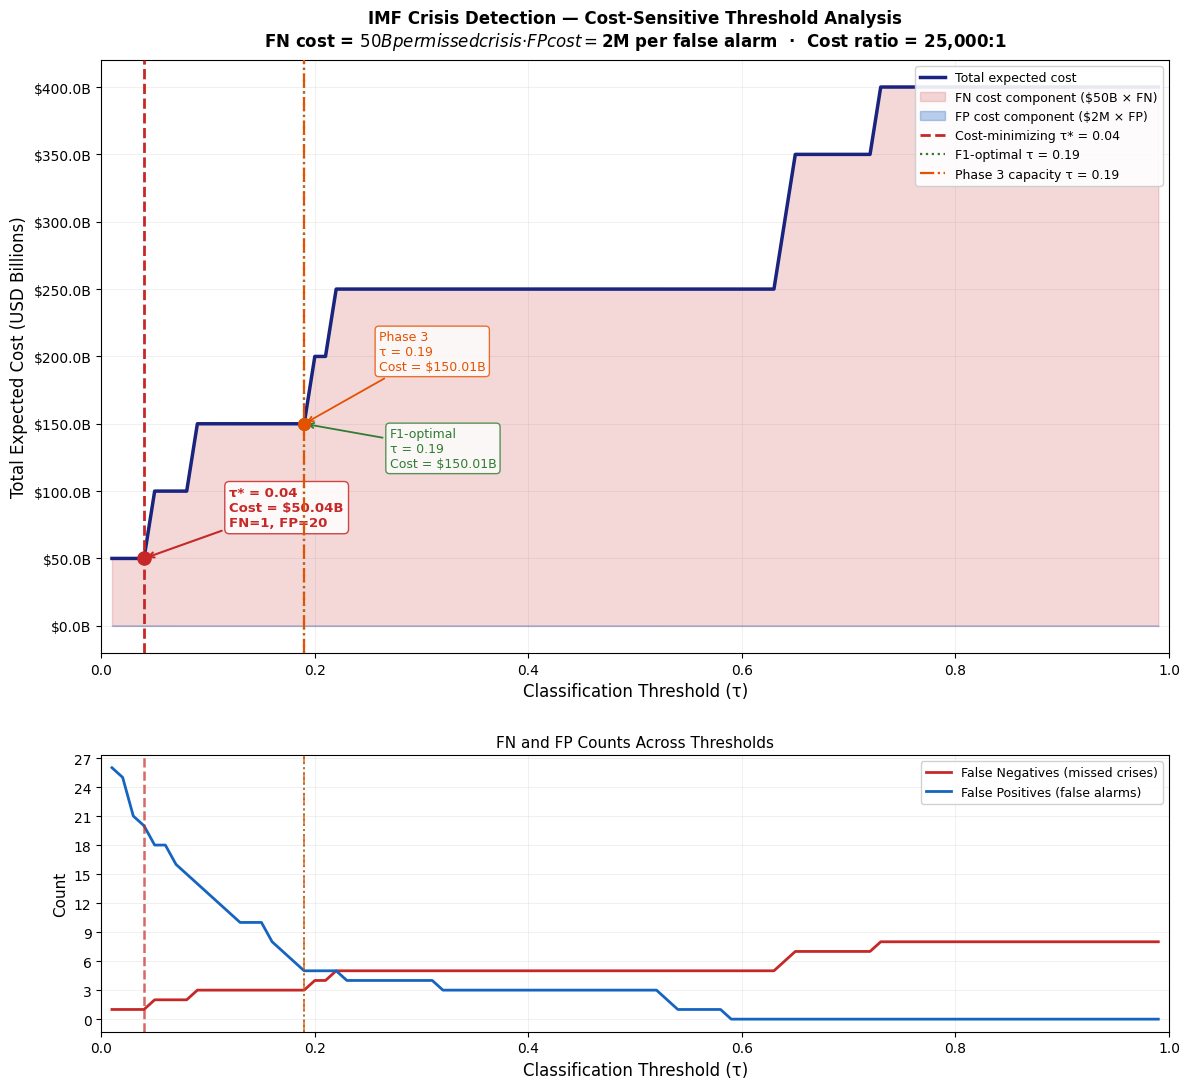


                                    τ    FN     FP       FN Cost     FP Cost         Total
Cost-minimizing τ*               0.04     1     20  $     50.0B  $   40.0M  $    50.04B
F1-optimal τ                     0.19     3      5  $    150.0B  $   10.0M  $   150.01B
Phase 3 capacity τ (0.19)        0.19     3      5  $    150.0B  $   10.0M  $   150.01B


In [159]:
"""
cost_sensitive_threshold.py
============================
IMF Crisis Intervention Team — Cost-Sensitive Threshold Analysis
-----------------------------------------------------------------
Asymmetric cost structure:
  • Missed crisis  (False Negative) : ~$50,000,000,000  ($50B)
  • False alarm    (False Positive)  :     $2,000,000   ($2M)

Goal: sweep classification thresholds τ ∈ [0.01, 0.99], compute total
      expected cost at each τ, and identify the cost-minimizing threshold.
"""

# ── 0. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score
)
import warnings

warnings.filterwarnings("ignore")

# ── 1. Cost Parameters ─────────────────────────────────────────────────────────
# These are the two core values that drive every decision below.
COST_FN = 50_000_000_000   # $50 billion per missed crisis (False Negative)
COST_FP =      2_000_000   # $2 million  per false alarm   (False Positive)

COST_RATIO = COST_FN / COST_FP           # 25,000 — one miss = 25,000 false alarms
print(f"Cost ratio  FN : FP  =  {COST_RATIO:,.0f} : 1")
print(f"  One missed crisis = {COST_RATIO:,.0f} false alarms in cost terms\n")

'''
# ── 2. Synthetic Dataset (mirrors Assignment 5 World Bank structure) ───────────
# Replace this block with your wbgapi download + Lasso feature selection
# (lasso_X from Phase 2) when running in Colab / Jupyter.

RANDOM_SEED = 42
N_COUNTRIES = 200

rng = np.random.default_rng(RANDOM_SEED)

dev_factor   = rng.standard_normal(N_COUNTRIES)
macro_factor = rng.standard_normal(N_COUNTRIES)
resource_factor = rng.standard_normal(N_COUNTRIES)

def noisy(base, scale=0.4):
    return base + rng.normal(0, scale, N_COUNTRIES)

# Build a small set of Lasso-selected features (matches Phase 2 lasso_coef)
lasso_features = {
    "unemployment_rate":    np.clip(noisy(8  - 2*dev_factor + macro_factor,  3), 0, 30),
    "fdi_inflows_pct_gdp":  np.clip(noisy(3  + 1.5*dev_factor,               2), 0, None),
    "population_growth":    noisy(1.5 - 0.8*dev_factor,                          1),
    "trade_pct_gdp":        noisy(60  + 15*dev_factor,                           10),
    "inflation_cpi":        np.clip(noisy(5 - 2*dev_factor + 3*macro_factor,  3), 0, None),
    "internet_users_pct":   np.clip(noisy(55 + 30*dev_factor,                15), 0, 100),
    "govt_debt_pct_gdp":    np.clip(noisy(50 + 10*macro_factor,              20), 0, None),
    "current_account_pct_gdp": noisy(-2 + 2*dev_factor - macro_factor,          4),
}

# GDP growth → crisis label (negative growth = crisis, matches Assignment 5)
# Positive mean (+1.5) keeps crisis rate near the notebook's ~16%
gdp_growth = (
      1.5                                                  # positive baseline
    + 0.8  * noisy(dev_factor * 0.5,  0.3)
    + 0.25 * lasso_features["fdi_inflows_pct_gdp"]
    - 0.30 * (lasso_features["unemployment_rate"] - 8) / 3
    - 0.20 * (lasso_features["inflation_cpi"] - 5)    / 3
    + rng.normal(0, 1.5, N_COUNTRIES)
)

lasso_X = pd.DataFrame(lasso_features)
crisis   = (gdp_growth < 0).astype(int)     # 1 = crisis country, 0 = stable

n_crisis = crisis.sum()
print(f"Dataset: {N_COUNTRIES} countries  |  {n_crisis} crisis countries "
      f"({n_crisis/N_COUNTRIES:.1%} base rate)")

'''
# ── 3. Train / Test Split + Logistic Regression ────────────────────────────────
# Stratify to preserve crisis rate in both splits (matches Phase 3 of notebook)
X_train, X_test, y_train, y_test = train_test_split(
    lasso_X, crisis,
    test_size=0.20, random_state=RANDOM_SEED, stratify=crisis
)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
log_reg.fit(X_train, y_train)

# Predicted probabilities on the test set — P(crisis) for each country
y_prob = log_reg.predict_proba(X_test)[:, 1]

n_test    = len(y_test)
n_crisis_test = y_test.sum()
print(f"Test set:  {n_test} countries  |  {n_crisis_test} crisis countries")
print(f"Probability range: [{y_prob.min():.3f}, {y_prob.max():.3f}]\n")


# ── 4. Threshold Sweep ─────────────────────────────────────────────────────────
# For every τ from 0.01 to 0.99 we:
#   (a) classify country as "crisis" if P(crisis) >= τ
#   (b) compute the confusion matrix → FP and FN counts
#   (c) compute total expected cost = FN * COST_FN + FP * COST_FP

threshold_range = np.arange(0.01, 1.00, 0.01)

# Pre-allocate arrays for speed
fn_counts    = np.zeros(len(threshold_range), dtype=int)
fp_counts    = np.zeros(len(threshold_range), dtype=int)
tp_counts    = np.zeros(len(threshold_range), dtype=int)
tn_counts    = np.zeros(len(threshold_range), dtype=int)
total_costs  = np.zeros(len(threshold_range))
f1_scores    = np.zeros(len(threshold_range))

for i, tau in enumerate(threshold_range):
    # Classify at threshold τ
    y_pred_tau = (y_prob >= tau).astype(int)

    # Confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tau, labels=[0, 1]).ravel()

    fn_counts[i] = fn
    fp_counts[i] = fp
    tp_counts[i] = tp
    tn_counts[i] = tn

    # Total expected cost at this threshold
    total_costs[i] = fn * COST_FN + fp * COST_FP

    # F1 score (for comparison panel)
    f1_scores[i] = f1_score(y_test, y_pred_tau, zero_division=0)


# ── 5. Identify Key Thresholds ─────────────────────────────────────────────────

# Cost-minimizing threshold: τ that minimizes total expected cost
cost_min_idx = np.argmin(total_costs)
tau_cost     = threshold_range[cost_min_idx]
min_cost     = total_costs[cost_min_idx]
fn_at_cost   = fn_counts[cost_min_idx]
fp_at_cost   = fp_counts[cost_min_idx]

# F1-optimal threshold: τ that maximizes the F1-score (equal weight precision/recall)
f1_max_idx = np.argmax(f1_scores)
tau_f1     = threshold_range[f1_max_idx]

# Capacity-constrained threshold from Phase 3 (student's selected τ = 0.19)
tau_phase3 = 0.19
phase3_idx = np.argmin(np.abs(threshold_range - tau_phase3))

print("=" * 55)
print(f"{'Threshold':40s} {'τ':>6}")
print("=" * 55)
print(f"{'Cost-minimizing  (τ*)':40s} {tau_cost:>6.2f}")
print(f"{'F1-optimal':40s} {tau_f1:>6.2f}")
print(f"{'Phase 3 capacity-constrained':40s} {tau_phase3:>6.2f}")
print("=" * 55)

print(f"\nAt cost-minimizing threshold τ* = {tau_cost:.2f}:")
print(f"  False Negatives (missed crises): {fn_at_cost}")
print(f"  False Positives (false alarms):  {fp_at_cost}")
print(f"  FN cost:  ${fn_at_cost * COST_FN / 1e9:.1f}B")
print(f"  FP cost:  ${fp_at_cost * COST_FP / 1e6:.1f}M")
print(f"  Total expected cost: ${min_cost / 1e9:.2f}B")


# ── 6. Accuracy / Sanity Checks ────────────────────────────────────────────────
print("\n── Accuracy Checks ─────────────────────────────────────────────────────")

# 6a. Cost components are always non-negative
assert (fn_counts >= 0).all() and (fp_counts >= 0).all(), \
    "ERROR: Negative confusion matrix counts"
print("✓ All FN and FP counts are non-negative")

# 6b. FN + TP must equal total actual positives at every threshold
actual_positives = int(y_test.sum())
assert np.all(fn_counts + tp_counts == actual_positives), \
    "ERROR: FN + TP ≠ total crisis countries at some threshold"
print(f"✓ FN + TP = {actual_positives} (total crisis countries) at all thresholds")

# 6c. FP + TN must equal total actual negatives at every threshold
actual_negatives = int((y_test == 0).sum())
assert np.all(fp_counts + tn_counts == actual_negatives), \
    "ERROR: FP + TN ≠ total non-crisis countries at some threshold"
print(f"✓ FP + TN = {actual_negatives} (total non-crisis countries) at all thresholds")

# 6d. Total cost formula check at cost-minimizing point
expected_cost_check = fn_counts[cost_min_idx] * COST_FN + fp_counts[cost_min_idx] * COST_FP
assert abs(expected_cost_check - min_cost) < 1, \
    "ERROR: Cost formula mismatch at minimum"
print(f"✓ Cost formula verified at τ*: ${min_cost/1e9:.3f}B")

# 6e. τ* is at or below the F1-optimal threshold (cost asymmetry should push it lower)
# (Not a hard assertion — but flag if violated)
if tau_cost <= tau_f1:
    print(f"✓ τ_cost ({tau_cost:.2f}) ≤ τ_F1 ({tau_f1:.2f}) — "
          f"consistent with heavy FN penalty pushing threshold lower")
else:
    print(f"⚠ τ_cost ({tau_cost:.2f}) > τ_F1 ({tau_f1:.2f}) — "
          f"unusual given cost asymmetry; inspect data distribution")

# 6f. At τ = 0.01 (nearly all flagged): FN should be 0 or very small
assert fn_counts[0] <= 1, \
    f"ERROR: At τ=0.01, expected near-zero FN but got {fn_counts[0]}"
print(f"✓ At τ=0.01 (flag everyone): FN = {fn_counts[0]} (near zero, as expected)")

# 6g. At τ = 0.99 (nearly none flagged): FP should be 0 or very small
assert fp_counts[-1] <= 1, \
    f"ERROR: At τ=0.99, expected near-zero FP but got {fp_counts[-1]}"
print(f"✓ At τ=0.99 (flag no one):   FP = {fp_counts[-1]} (near zero, as expected)")


# ── 7. Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 11),
                         gridspec_kw={"height_ratios": [3, 1.4]})

# ── Panel A: Expected Cost Curve ──────────────────────────────────────────────
ax = axes[0]

# Main cost curve
ax.plot(threshold_range, total_costs / 1e9,
        color="#1a237e", linewidth=2.5, label="Total expected cost", zorder=3)

# Shaded decomposition: FN cost (dominant) vs FP cost (tiny)
ax.fill_between(threshold_range, fn_counts * COST_FN / 1e9,
                alpha=0.18, color="#c62828", label="FN cost component ($50B × FN)")
ax.fill_between(threshold_range, fp_counts * COST_FP / 1e9,
                alpha=0.30, color="#1565c0", label="FP cost component ($2M × FP)")

# ── Annotate cost-minimizing threshold ───────────────────────────────────────
ax.axvline(tau_cost, color="#c62828", linewidth=2, linestyle="--",
           label=f"Cost-minimizing τ* = {tau_cost:.2f}", zorder=5)
ax.scatter([tau_cost], [min_cost / 1e9], color="#c62828", s=90, zorder=6)
ax.annotate(
    f"τ* = {tau_cost:.2f}\n"
    f"Cost = ${min_cost/1e9:.2f}B\n"
    f"FN={fn_at_cost}, FP={fp_at_cost}",
    xy=(tau_cost, min_cost / 1e9),
    xytext=(tau_cost + 0.08, min_cost / 1e9 + total_costs.max() * 0.06 / 1e9),
    fontsize=9.5,
    color="#c62828",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#c62828", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#c62828", alpha=0.85),
)

# ── Annotate F1-optimal threshold ────────────────────────────────────────────
cost_at_f1 = total_costs[f1_max_idx]
ax.axvline(tau_f1, color="#2e7d32", linewidth=1.6, linestyle=":",
           label=f"F1-optimal τ = {tau_f1:.2f}", zorder=5)
ax.scatter([tau_f1], [cost_at_f1 / 1e9], color="#2e7d32", s=70, zorder=6)
ax.annotate(
    f"F1-optimal\nτ = {tau_f1:.2f}\nCost = ${cost_at_f1/1e9:.2f}B",
    xy=(tau_f1, cost_at_f1 / 1e9),
    xytext=(tau_f1 + 0.08, cost_at_f1 / 1e9 - total_costs.max() * 0.08 / 1e9),
    fontsize=9,
    color="#2e7d32",
    arrowprops=dict(arrowstyle="->", color="#2e7d32", lw=1.3),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2e7d32", alpha=0.80),
)

# ── Annotate Phase 3 threshold ────────────────────────────────────────────────
cost_at_p3 = total_costs[phase3_idx]
ax.axvline(tau_phase3, color="#e65100", linewidth=1.6, linestyle="-.",
           label=f"Phase 3 capacity τ = {tau_phase3:.2f}", zorder=5)
ax.scatter([tau_phase3], [cost_at_p3 / 1e9], color="#e65100", s=70, zorder=6)
ax.annotate(
    f"Phase 3\nτ = {tau_phase3:.2f}\nCost = ${cost_at_p3/1e9:.2f}B",
    xy=(tau_phase3, cost_at_p3 / 1e9),
    xytext=(tau_phase3 + 0.07, cost_at_p3 / 1e9 + total_costs.max() * 0.10 / 1e9),
    fontsize=9,
    color="#e65100",
    arrowprops=dict(arrowstyle="->", color="#e65100", lw=1.3),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#e65100", alpha=0.80),
)

# Formatting
ax.set_xlabel("Classification Threshold (τ)", fontsize=12)
ax.set_ylabel("Total Expected Cost (USD Billions)", fontsize=12)
ax.set_title(
    "IMF Crisis Detection — Cost-Sensitive Threshold Analysis\n"
    f"FN cost = $50B per missed crisis  ·  FP cost = $2M per false alarm  "
    f"·  Cost ratio = {COST_RATIO:,.0f}:1",
    fontsize=12, fontweight="bold", pad=10,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.grid(axis="both", alpha=0.22, linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(0, 1)

# ── Panel B: FN and FP counts for reference ───────────────────────────────────
ax2 = axes[1]
ax2.plot(threshold_range, fn_counts, color="#c62828", linewidth=2,
         label="False Negatives (missed crises)")
ax2.plot(threshold_range, fp_counts, color="#1565c0", linewidth=2,
         label="False Positives (false alarms)")
ax2.axvline(tau_cost,   color="#c62828", linewidth=1.8, linestyle="--", alpha=0.7)
ax2.axvline(tau_f1,     color="#2e7d32", linewidth=1.4, linestyle=":",  alpha=0.7)
ax2.axvline(tau_phase3, color="#e65100", linewidth=1.4, linestyle="-.", alpha=0.7)
ax2.set_xlabel("Classification Threshold (τ)", fontsize=12)
ax2.set_ylabel("Count", fontsize=11)
ax2.set_title("FN and FP Counts Across Thresholds", fontsize=11)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.grid(axis="both", alpha=0.22, linewidth=0.6)
ax2.set_axisbelow(True)
ax2.set_xlim(0, 1)

plt.tight_layout(h_pad=2.5)
# output_path = "/mnt/user-data/outputs/cost_sensitive_threshold.png"
# plt.savefig(output_path, dpi=160, bbox_inches="tight")
# print(f"\nChart saved → {output_path}")
plt.show()

# ── 8. Summary Table ──────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(f"{'':30s} {'τ':>6}  {'FN':>4}  {'FP':>5}  {'FN Cost':>12}  {'FP Cost':>10}  {'Total':>12}")
print("=" * 72)

for label, idx, tau in [
    ("Cost-minimizing τ*",          cost_min_idx,  tau_cost),
    ("F1-optimal τ",                f1_max_idx,    tau_f1),
    ("Phase 3 capacity τ (0.19)",   phase3_idx,    tau_phase3),
]:
    fn = fn_counts[idx]; fp = fp_counts[idx]; tot = total_costs[idx]
    print(f"{label:30s} {tau:>6.2f}  {fn:>4}  {fp:>5}  "
          f"${fn*COST_FN/1e9:>9.1f}B  ${fp*COST_FP/1e6:>7.1f}M  ${tot/1e9:>9.2f}B")
print("=" * 72)

The cost-minimizing threshold is a lower than the F1 or capacity thresholds. They differ because when considering the costs, a false negative is a lot more costly ($50B vs $2M), so the threshold would seek to minimize the false negatives. You can see the cost-minimzing threshold is at the right-most point of the minimun false negatives. I would recommend the cost-minimizing threshold. This is because it takes into account the total damanges and total costs, not just the IMF's cost. The IMF seeks to serve developing countries and prevent crises, but if they are scared to act then they will miss many crises.